Feature Preparation:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("../data/final/cleaned_dataset.csv")
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Month'] = df['Transaction_Date'].dt.month
df['DayOfWeek'] = df['Transaction_Date'].dt.dayofweek # 0: Thứ 2, ..., 6: Chủ Nhật
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0) # 1 nếu T7/CN, 0 nếu ngày thường


Train/Test Split:

In [3]:
feature_cols = [ 'Original_Price_VND', 'Discount_Ratio',
                 'Age', 'Month', 'DayOfWeek', 'Is_Weekend'
]

X = df[feature_cols].copy()
y = df['Revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Kích thước tập Train: {X_train.shape}, Tập Test: {X_test.shape}")

Kích thước tập Train: (8000, 6), Tập Test: (2000, 6)


So sánh mô hình: Huấn luyện và so sánh LinearRegression vs DecisionTreeRegressor.

In [4]:
# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
# 2. Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

Đánh giá mô hình bằng các chỉ số: MSE, RMSE, R².

In [6]:
# Tính toán chỉ số MSE, RMSE, R²
def evaluate_performance(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'R2_Score': r2}

results_df = pd.DataFrame([
    evaluate_performance(y_test, y_pred_lr, 'Linear Regression'),
    evaluate_performance(y_test, y_pred_dt, 'Decision Tree Regressor')
])

print("\n" + "=" * 65)
print("       BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG MÔ HÌNH")
print("=" * 65)

for _, row in results_df.iterrows():
    print(f"\nMô hình: {row['Model']}")
    print(f"  MSE     : {row['MSE']:,.2f}")
    print(f"  RMSE    : {row['RMSE']:,.2f}")
    print(f"  R² Score: {row['R2_Score']:.4f}")

print("\n" + "=" * 65)


       BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG MÔ HÌNH

Mô hình: Linear Regression
  MSE     : 5,964,891,604,240.36
  RMSE    : 2,442,312.76
  R² Score: 0.8095

Mô hình: Decision Tree Regressor
  MSE     : 10,876,823,717,571.34
  RMSE    : 3,298,002.99
  R² Score: 0.6526



Trực quan hóa

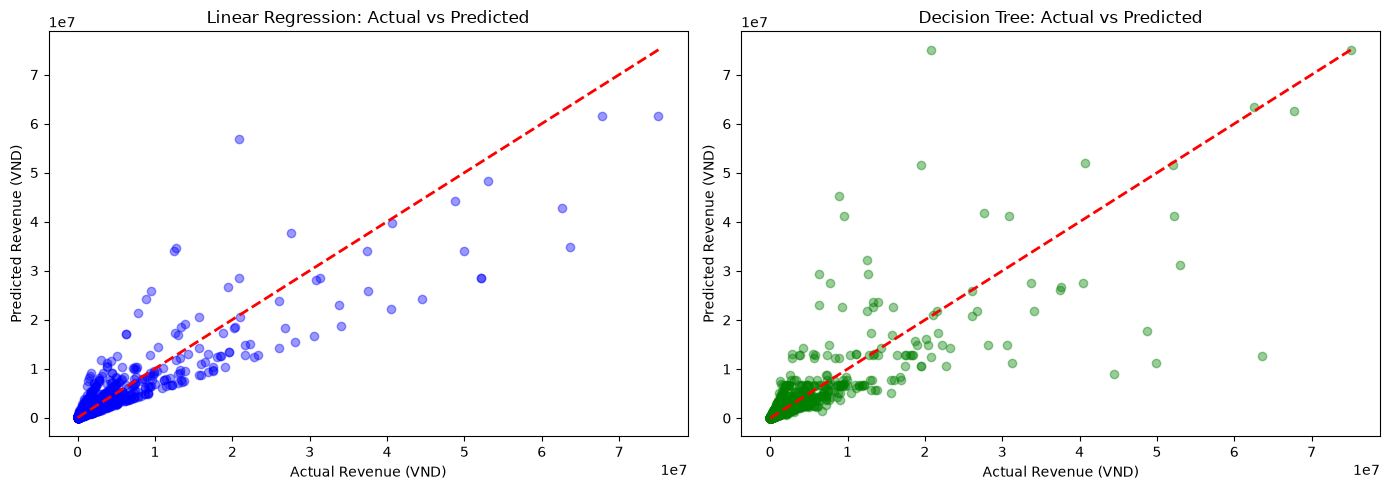

In [8]:
plt.figure(figsize=(14, 5))

# Biểu đồ 1: Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='blue')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2
)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Revenue (VND)')
plt.ylabel('Predicted Revenue (VND)')

# Biểu đồ 2: Decision Tree
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='green')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', lw=2
)
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Revenue (VND)')
plt.ylabel('Predicted Revenue (VND)')

plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path

# So sánh và chọn mô hình có R² cao hơn
if results_df.loc[1, 'R2_Score'] > results_df.loc[0, 'R2_Score']:
    best_model = dt_model
    best_name = 'Decision Tree Regressor'
else:
    best_model = lr_model
    best_name = 'Linear Regression'

print(f"\nMô hình được chọn: {best_name}")

# Lưu mô hình theo cấu trúc dự án
model_dir = Path("../src/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "regression_model.pkl"
joblib.dump(best_model, model_path)

print(f"Đã lưu mô hình tại: {model_path}")


Mô hình được chọn: Linear Regression
Đã lưu mô hình tại: ..\src\models\regression_model.pkl


**Linear Regression là mô hình có hiệu năng tốt hơn Decision Tree Regressor vì:**

* **R² Score cao hơn:** đạt 0.8095 so với 0.6526, chênh lệch khoảng **0.1569 điểm** (tương đương 15.69 điểm phần trăm).
* **RMSE thấp hơn:** khoảng 2.442.313 VND so với 3.298.003 VND, cho thấy mức sai số dự đoán điển hình thấp hơn.
* **MSE thấp hơn:** khoảng \(5.96 \times 10^{12}\) so với \(1.09 \times 10^{13}\), cho thấy sai số bình phương trung bình thấp hơn.

**Kết luận:** Linear Regression được chọn làm mô hình hồi quy tốt nhất trong hai mô hình thử nghiệm trên tập dữ liệu kiểm tra.
